Accuracy: 0.95

Confusion Matrix:
 [[12  1]
 [ 0  7]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.92      0.96        13
           1       0.88      1.00      0.93         7

    accuracy                           0.95        20
   macro avg       0.94      0.96      0.95        20
weighted avg       0.96      0.95      0.95        20



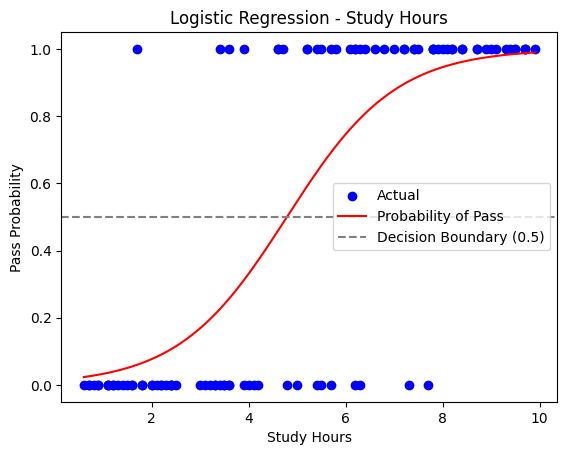

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load data
df = pd.read_csv('studyhours.csv')
x = df[['Study_Hours']].values
y = df['Pass'].values

# Train/test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Train model
model = LogisticRegression()
model.fit(x_train, y_train)

# Predict
y_pred = model.predict(x_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Plot
x_line = np.linspace(x.min(), x.max(), 300).reshape(-1, 1)
y_prob = model.predict_proba(x_line)[:, 1]  

# probability of Pass=1
plt.scatter(x, y, color='blue', label='Actual', zorder=2)
plt.plot(x_line, y_prob, color='red', label='Probability of Pass')
plt.axhline(0.5, color='gray', linestyle='--', label='Decision Boundary (0.5)')
plt.xlabel('Study Hours')
plt.ylabel('Pass Probability')
plt.title('Logistic Regression - Study Hours')
plt.legend()
plt.show()
